In [29]:
import pandas as pd
import numpy as np

dict_bkg = pd.read_pickle("/nfs/pic.es/user/v/varom/NormFlows/run3flows/results/TwoLep_OS_processed/TwoLep_OS_processed_NFs_SplusB/Run_1835-27-07-2026/evaluation_outputs/saved_outputs.pkl", compression=None)
print(dict_bkg.keys())

dict_keys(['data', 'loss', 'ad_score', 'weights', 'eventNumber', 'samples', 'groups'])


In [30]:
print(dict_bkg['ad_score'])

[ -1.57889938  -8.37365723  -4.4925108  ...  -7.26849127 -17.70300484
  -9.27877617]


In [31]:
def scale_log_prob(log_probs, min_prob=None, max_prob=None, use_01=True, 
                    lower_pct=0.1, upper_pct=99.9):
    if use_01:
        log_probs = -log_probs

    if min_prob is None:
        min_prob = np.percentile(log_probs, lower_pct)
        max_prob = np.percentile(log_probs, upper_pct)

    scaled = (log_probs - min_prob) / (max_prob - min_prob)
    scaled = np.clip(scaled, 0, 1)  # los outliers se saturan en 0 o 1, no explotan fuera de rango
    print(f"Scaled loglikelihood using {min_prob} , {max_prob} to mean: {scaled.mean()}")
    return scaled, min_prob, max_prob


dict_bkg['ad_score'], _ , _ = scale_log_prob(dict_bkg['ad_score'])

print(dict_bkg['ad_score'])

Scaled loglikelihood using -20.63685648536682 , 73.61185884094272 to mean: 0.2330203583217534
[0.23571415 0.30780805 0.26662822 ... 0.296082   0.40679452 0.31741157]


In [32]:
import pickle
import sklearn

import pickle
import os

main_path = "/nfs/pic.es/user/v/varom/NormFlows/run3flows/results/TwoLep_OS_processed/TwoLep_OS_processed_NFs_SplusB/Run_1835-27-07-2026/scalers"

variables = [
    'L2_RJ_ISR_pt_NOSYS',
    'L2_RJ_MTS_NOSYS',
    'L2_RJ_R_ISR_NOSYS',
    'L2_met_HTLeptons_NOSYS',
    'L2_mt2_NOSYS',
    'met_GeV_NOSYS',
]

training_variables = {var: {} for var in variables}

for var in training_variables:
    with open(os.path.join(main_path, f"{var}_scaler.pkl"), "rb") as f:
        training_variables[var]["scaler"] = pickle.load(f)

bkg_dict = {
    "variables": training_variables,
    "loss": dict_bkg["loss"],
    "ad_score": dict_bkg["ad_score"],
    "weights": dict_bkg["weights"],
    "eventNumber": dict_bkg["eventNumber"],
    "samples": dict_bkg["samples"],
    "groups": dict_bkg["groups"],
}

for i, var in enumerate(variables):
    bkg_dict["variables"][var]["data"] = dict_bkg["data"][:, i]



In [33]:
print(bkg_dict['variables']['L2_RJ_MTS_NOSYS'])

{'scaler': StandardScaler(), 'data': array([-0.20007503,  1.291481  , -0.13110435, ...,  0.6339837 ,
        4.058053  ,  2.2978773 ], dtype=float32)}


In [34]:
for var in bkg_dict["variables"]:

    scaler = bkg_dict["variables"][var]["scaler"]
    data = bkg_dict["variables"][var]["data"]

    bkg_dict["variables"][var]["data_unscaled"] = (
        scaler.inverse_transform(data.reshape(-1, 1)).ravel()
    )

In [35]:
print(bkg_dict['variables']['L2_RJ_MTS_NOSYS'])

{'scaler': StandardScaler(), 'data': array([-0.20007503,  1.291481  , -0.13110435, ...,  0.6339837 ,
        4.058053  ,  2.2978773 ], dtype=float32), 'data_unscaled': array([140.7331 , 374.38773, 151.53746, ..., 271.3897 , 807.77563,
       532.0413 ], dtype=float32)}


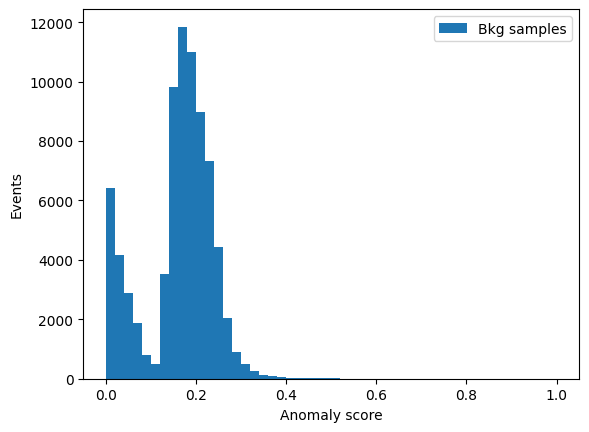

In [36]:
import matplotlib.pyplot as plt


mask_low_adscore = bkg_dict["ad_score"] < 0.22
mask_high_adscore = ~mask_low_adscore

low = np.sum(mask_low_adscore)*100 / (np.sum(mask_low_adscore)+np.sum(mask_high_adscore))
high = np.sum(mask_high_adscore)*100 / (np.sum(mask_low_adscore)+np.sum(mask_high_adscore))

plt.hist(bkg_dict['ad_score'], bins=50,weights=bkg_dict['weights'],label="Bkg samples")
plt.xlabel("Anomaly score")
plt.ylabel("Events")
#plt.yscale("log")
plt.legend()
plt.show()

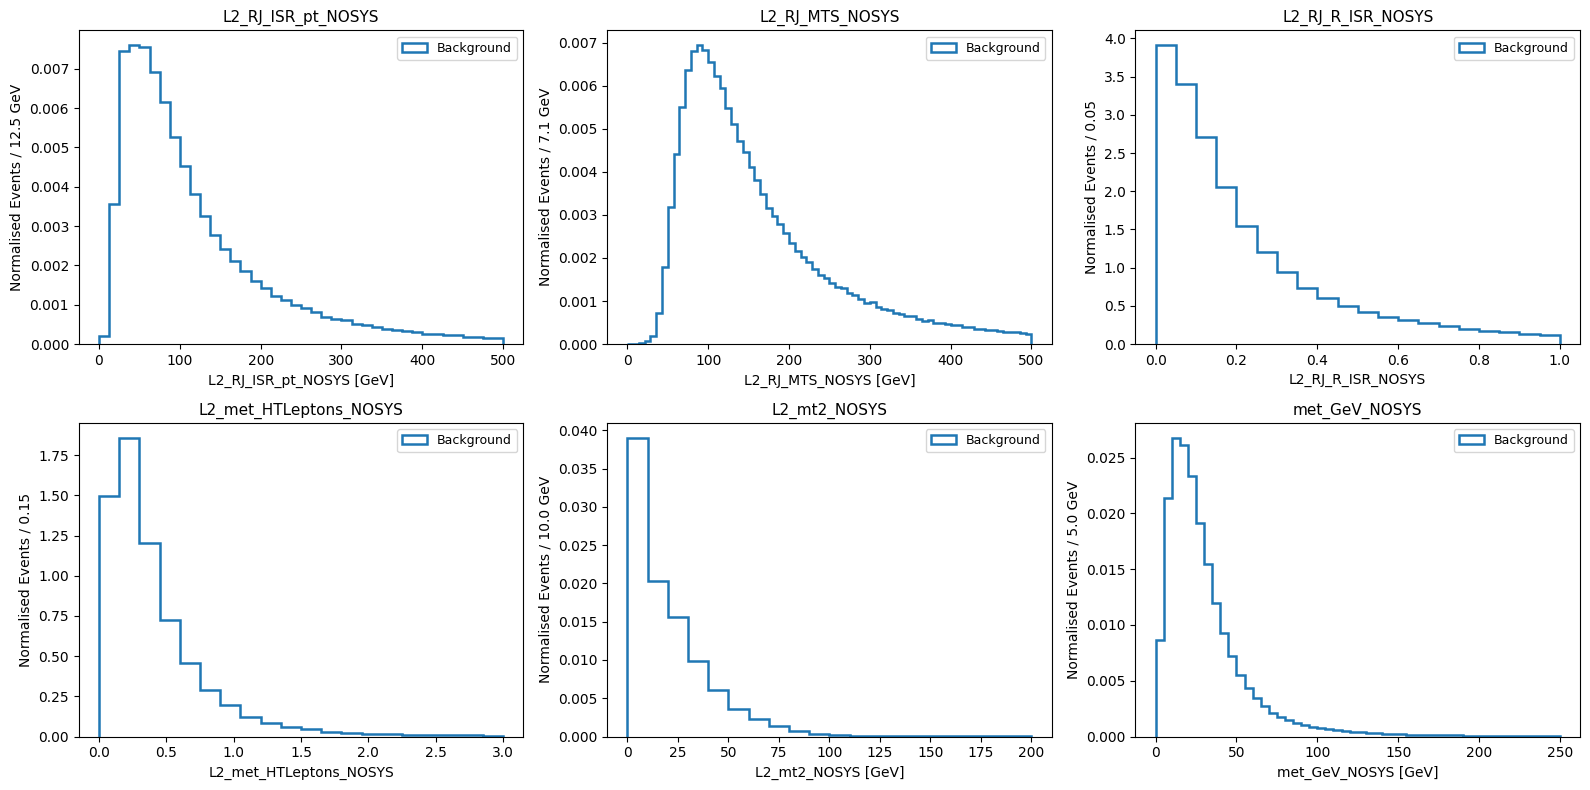

In [37]:
ranges = {
    "L2_RJ_ISR_pt_NOSYS": (0, 500),
    "L2_RJ_MTS_NOSYS": (0, 500),
    "L2_RJ_R_ISR_NOSYS": (0, 1),
    "L2_met_HTLeptons_NOSYS": (0, 3),
    "L2_mt2_NOSYS": (0, 200),
    "met_GeV_NOSYS": (0, 250),
}

n_bins = {
    "L2_RJ_ISR_pt_NOSYS": 40,
    "L2_RJ_MTS_NOSYS": 70,
    "L2_RJ_R_ISR_NOSYS": 20,
    "L2_met_HTLeptons_NOSYS": 20,
    "L2_mt2_NOSYS": 20,
    "met_GeV_NOSYS": 50,
}

units = {
    "L2_RJ_ISR_pt_NOSYS": 'GeV',
    "L2_RJ_MTS_NOSYS": 'GeV',
    "L2_RJ_R_ISR_NOSYS": None,
    "L2_met_HTLeptons_NOSYS": None,
    "L2_mt2_NOSYS": 'GeV',
    "met_GeV_NOSYS": 'GeV',
}

import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for ax, var in zip(axes, variables):

    ax.hist(
        bkg_dict["variables"][var]["data_unscaled"],
        bins=n_bins[var],
        range=ranges[var],
        density=True,
        histtype="step",
        linewidth=1.8,
        label="Background"
    )

    ax.set_title(var, fontsize=11)

    # Etiqueta del eje X
    if units[var] is None:
        ax.set_xlabel(var)
    else:
        ax.set_xlabel(f"{var} [{units[var]}]")

    # Anchura del bin para el eje Y
    bin_width = (ranges[var][1] - ranges[var][0]) / n_bins[var]

    if units[var] is None:
        ax.set_ylabel(f"Normalised Events / {bin_width:.2f}")
    else:
        ax.set_ylabel(f"Normalised Events / {bin_width:.1f} {units[var]}")

    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

## AS for the two regions

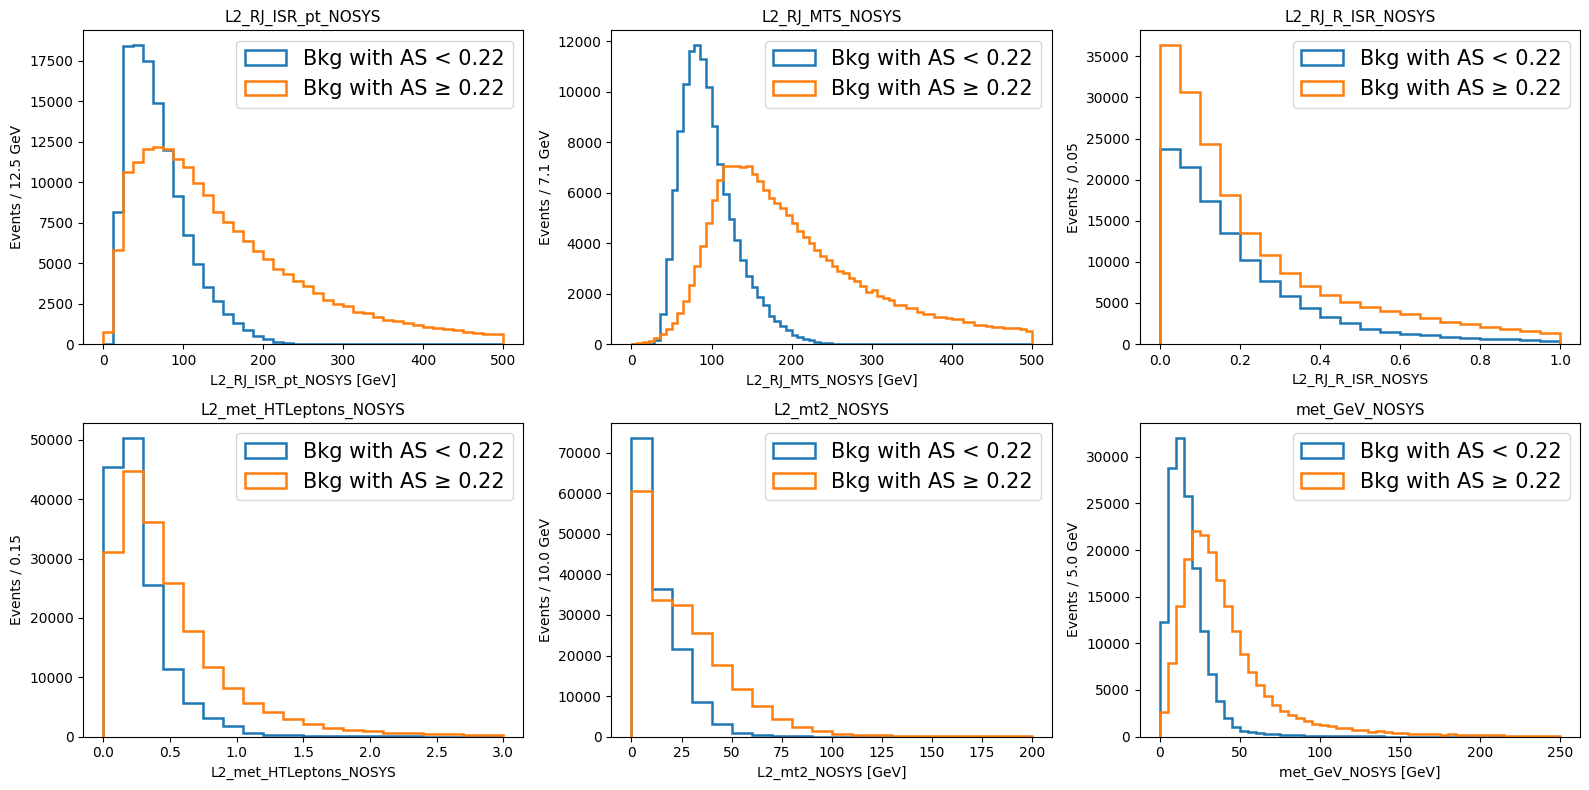

In [38]:
import matplotlib.pyplot as plt
import numpy as np

threshold = 0.22

mask_low = bkg_dict["ad_score"] < threshold
mask_high = bkg_dict["ad_score"] >= threshold

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for ax, var in zip(axes, variables):

    data = bkg_dict["variables"][var]["data_unscaled"]

    ax.hist(
        data[mask_low],
        bins=n_bins[var],
        range=ranges[var],
        #density=True,
        histtype="step",
        linewidth=1.8,
        label=f"Bkg with AS < {threshold}",
    )

    ax.hist(
        data[mask_high],
        bins=n_bins[var],
        range=ranges[var],
        #density=True,
        histtype="step",
        linewidth=1.8,
        label=f"Bkg with AS ≥ {threshold}",
    )

    ax.set_title(var, fontsize=11)

    if units[var] is None:
        ax.set_xlabel(var)
        ylabel = f"Events / {(ranges[var][1]-ranges[var][0])/n_bins[var]:.2f}"
    else:
        ax.set_xlabel(f"{var} [{units[var]}]")
        ylabel = (
            f"Events / "
            f"{(ranges[var][1]-ranges[var][0])/n_bins[var]:.1f} {units[var]}"
        )

    ax.set_ylabel(ylabel)
    ax.legend(fontsize=15)

plt.tight_layout()
plt.show()

## AS for a specific sample

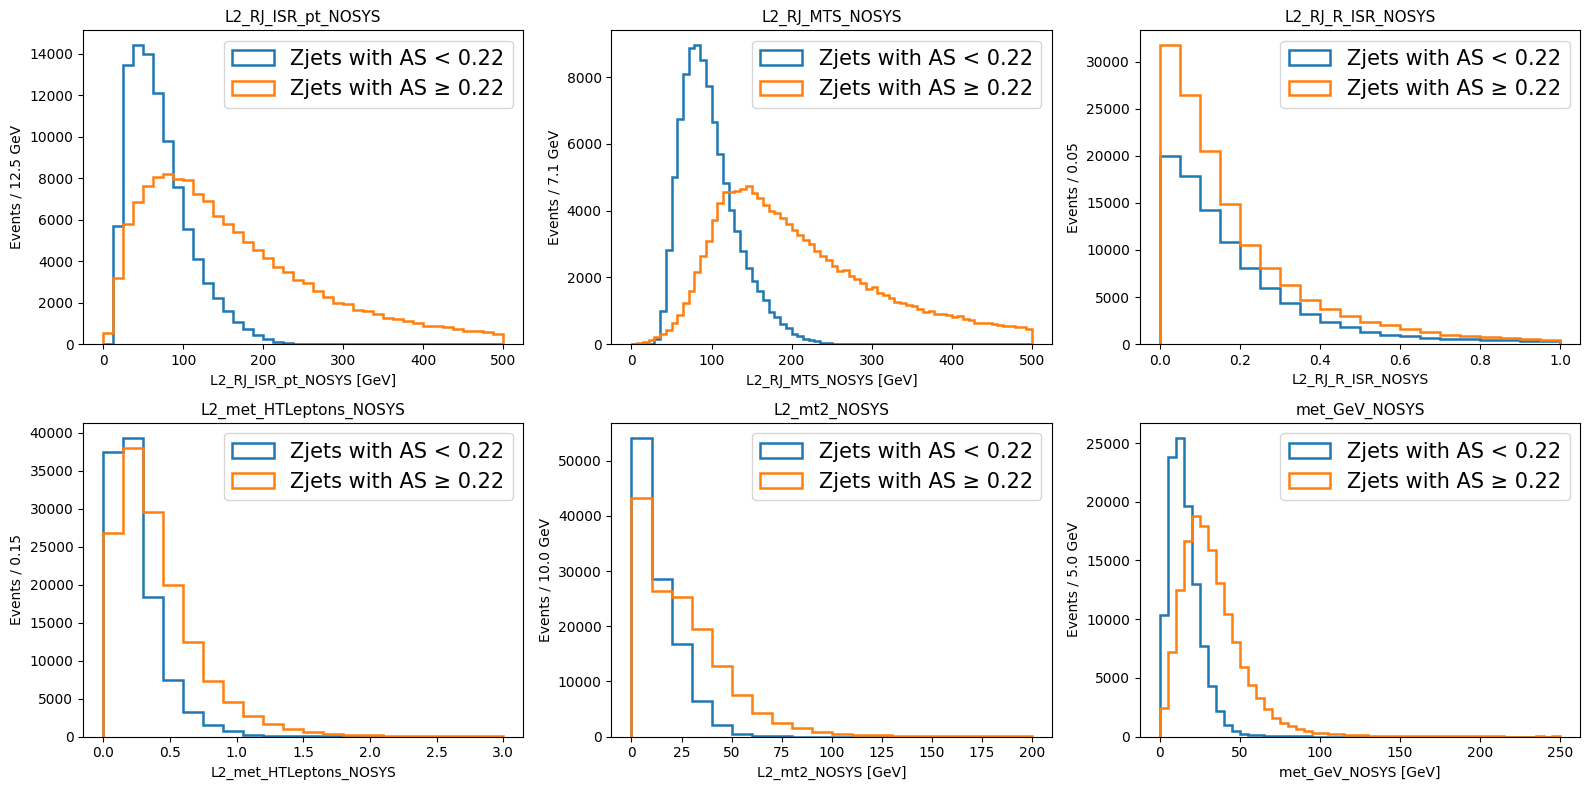

In [49]:
import matplotlib.pyplot as plt
import numpy as np

threshold = 0.22

mask_low = bkg_dict["ad_score"] < threshold
mask_high = bkg_dict["ad_score"] >= threshold

sample_mask = "Zjets"
mask_sample = bkg_dict["samples"] == sample_mask

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for ax, var in zip(axes, variables):

    data = bkg_dict["variables"][var]["data_unscaled"]

    ax.hist(
        data[mask_low & mask_sample] ,
        bins=n_bins[var],
        range=ranges[var],
        #density=True,
        histtype="step",
        linewidth=1.8,
        label=f"{sample_mask} with AS < {threshold}",
    )

    ax.hist(
        data[mask_high & mask_sample],
        bins=n_bins[var],
        range=ranges[var],
        #density=True,
        histtype="step",
        linewidth=1.8,
        label=f"{sample_mask} with AS ≥ {threshold}",
    )

    ax.set_title(var, fontsize=11)

    if units[var] is None:
        ax.set_xlabel(var)
        ylabel = f"Events / {(ranges[var][1]-ranges[var][0])/n_bins[var]:.2f}"
    else:
        ax.set_xlabel(f"{var} [{units[var]}]")
        ylabel = (
            f"Events / "
            f"{(ranges[var][1]-ranges[var][0])/n_bins[var]:.1f} {units[var]}"
        )

    ax.set_ylabel(ylabel)
    ax.legend(fontsize=15)

plt.tight_layout()
plt.show()

## Percentages of each sample in each region

In [40]:
mask_low = bkg_dict["ad_score"] < 0.22
mask_high = ~mask_low

for sample in np.unique(bkg_dict["samples"]):
    n_low = np.sum((bkg_dict["samples"] == sample) & mask_low)
    n_high = np.sum((bkg_dict["samples"] == sample) & mask_high)
    n_tot = n_low + n_high

    print(sample, f'{n_low*100/n_tot:.1f}% backward region', f'{n_high*100/n_tot:.1f}% forward region')

VV 32.7% backward region 67.3% forward region
VVV 21.8% backward region 78.2% forward region
Vy 57.2% backward region 42.8% forward region
Wjets 19.0% backward region 81.0% forward region
Zjets 42.7% backward region 57.3% forward region
higgs 44.2% backward region 55.8% forward region
othertop 13.6% backward region 86.4% forward region
singletop 25.0% backward region 75.0% forward region
ttbar 15.4% backward region 84.6% forward region


## Scatter plots

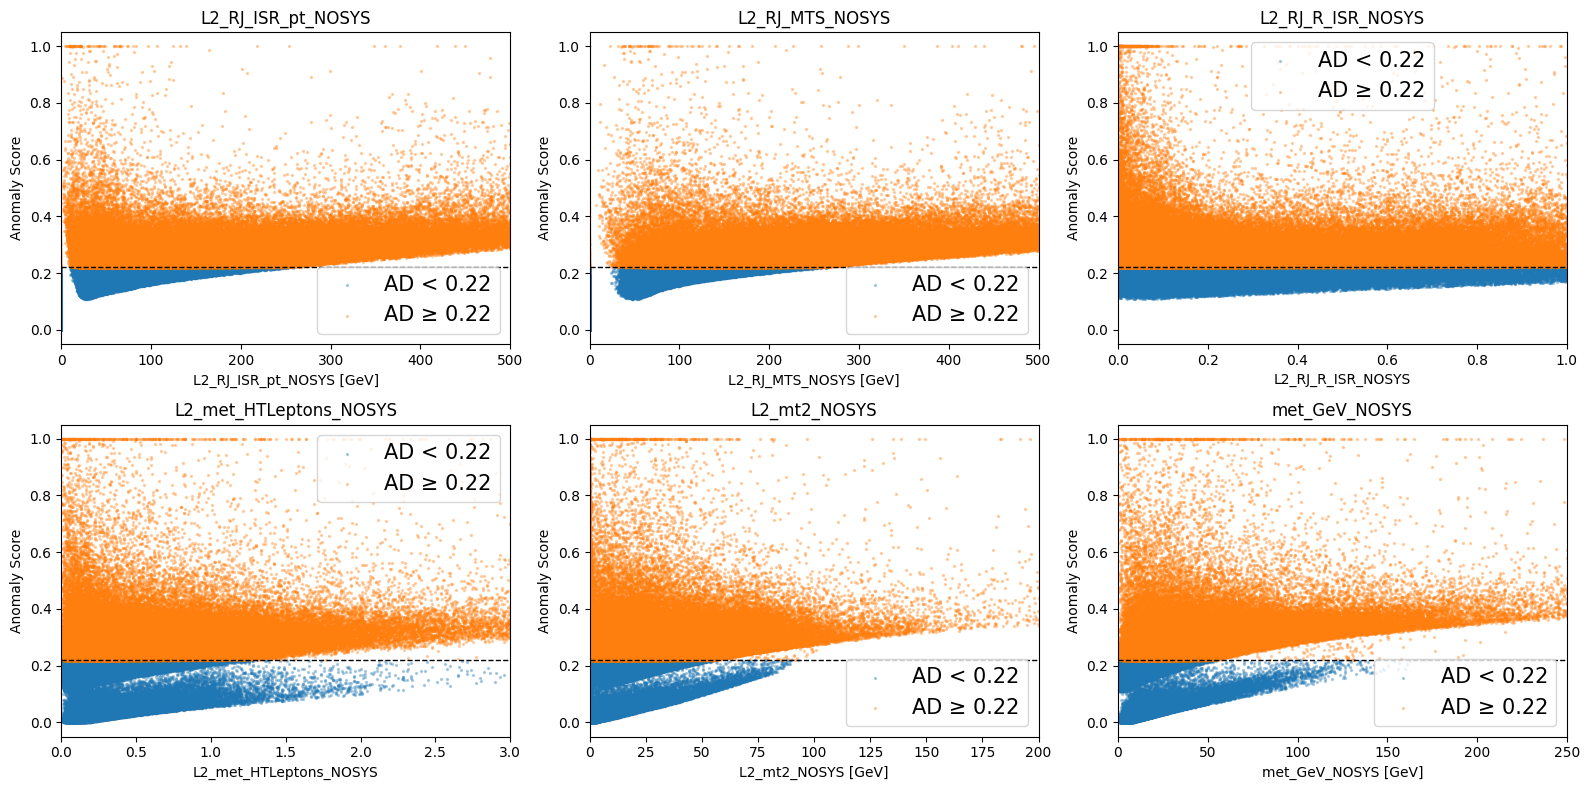

In [41]:
import matplotlib.pyplot as plt
import numpy as np

threshold = 0.22

mask_low = bkg_dict["ad_score"] < threshold
mask_high = ~mask_low

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for ax, var in zip(axes, variables):

    x = bkg_dict["variables"][var]["data_unscaled"]
    y = bkg_dict["ad_score"]

    ax.scatter(
        x[mask_low],
        y[mask_low],
        s=2,
        alpha=0.3,
        label=f"AD < {threshold}"
    )

    ax.scatter(
        x[mask_high],
        y[mask_high],
        s=2,
        alpha=0.3,
        label=f"AD ≥ {threshold}"
    )

    ax.axhline(threshold, color="black", ls="--", lw=1)

    ax.set_xlim(ranges[var])

    if units[var] is None:
        ax.set_xlabel(var)
    else:
        ax.set_xlabel(f"{var} [{units[var]}]")

    ax.set_ylabel("Anomaly Score")
    ax.set_title(var)
    ax.legend(fontsize=15)

plt.tight_layout()
plt.show()

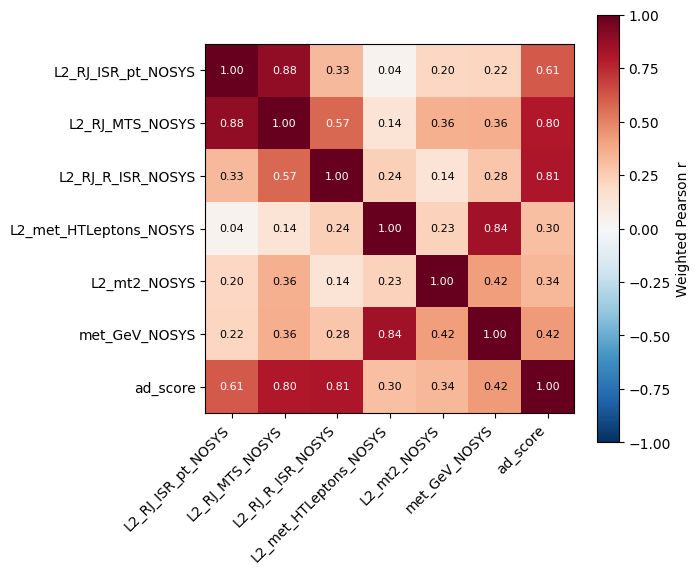

In [42]:
all_names = variables + ["ad_score"]
n = len(all_names)
corr_matrix = np.zeros((n, n))

data_arrays = [bkg_dict["variables"][v]["data_unscaled"] for v in variables] + [ad_score]

for i in range(n):
    for j in range(n):
        corr_matrix[i, j] = weighted_pearson(data_arrays[i], data_arrays[j], weights)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr_matrix, vmin=-1, vmax=1, cmap="RdBu_r")

ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(all_names, rotation=45, ha="right")
ax.set_yticklabels(all_names)

for i in range(n):
    for j in range(n):
        ax.text(j, i, f"{corr_matrix[i,j]:.2f}", ha="center", va="center",
                 color="white" if abs(corr_matrix[i,j]) > 0.5 else "black", fontsize=8)

fig.colorbar(im, ax=ax, label="Weighted Pearson r")
plt.tight_layout()
plt.show()

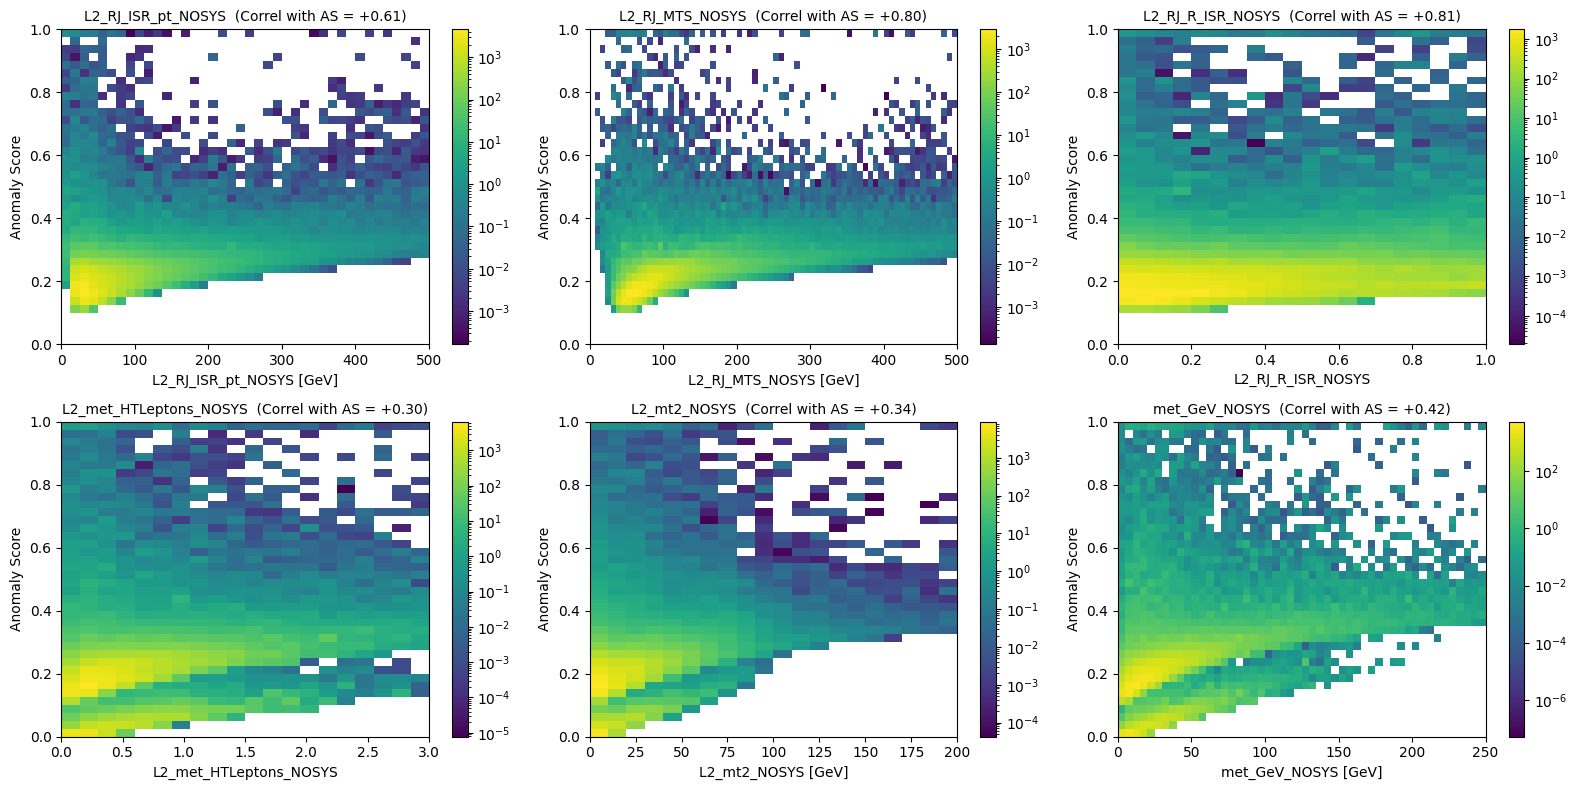

In [45]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for ax, var in zip(axes, variables):
    x = bkg_dict["variables"][var]["data_unscaled"]
    y = ad_score

    h = ax.hist2d(
        x, y,
        bins=[n_bins[var], 40],
        range=[ranges[var], (0, 1)],
        weights=weights,
        cmap="viridis",
        norm=plt.matplotlib.colors.LogNorm(),
    )
    fig.colorbar(h[3], ax=ax)

    r = correlations[var]
    ax.set_title(f"{var}  (Correl with AS = {r:+.2f})", fontsize=10)
    ax.set_xlabel(f"{var} [{units[var]}]" if units[var] else var)
    ax.set_ylabel("Anomaly Score")

plt.tight_layout()
plt.show()